# Replicating Tigges et al. (2023): a linear positive/negative direction in Gemma 2 2B

**Reference:** Tigges, Hollinsworth, Geiger & Nanda (2023), _Linear Representations of Sentiment in Large Language Models_ ([arXiv:2310.15154](https://arxiv.org/abs/2310.15154)).

This notebook is a standalone sanity check. Before the ordinal-intensity analysis in [`003_0405_braico.ipynb`](003_0405_braico.ipynb), we confirm that — on the binary `{negative, positive}` contrast the paper studied — our setup recovers the same core result (sentiment lives on a single linear direction), using the non-causal metrics our toolkit shares with theirs. Sections 1–2 are the same model/data setup as the braico notebook; section R is the replication.

## 1. Setup

Load dependencies and internal library modules:

- `data_typing` — typed `Sample` dataclass and JSONL loading utilities
- `representations` — forward-pass helpers that extract hidden-state activations at a given layer
- `analysis` — difference vectors, cosine similarity matrix, and plotting

In [ ]:
import json
import sys
from pathlib import Path

import torch

sys.path.insert(0, str(Path("..").resolve()))  # src/notebooks/ -> src/

from lib.sentences import Sample, LEVELS, load_accepted
from lib.representations import load_representations
from lib.analysis import (
    compute_difference_vectors, similarity_matrix, plot_similarity_matrix, cosine_sim,
    within_scenario_linearity_metrics, ordinal_linearity_metrics, acts_by_level_from_dict,
    scenario_triples, within_center, per_scenario_step_cosines,
)

### 1.1 Configuration

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `MODEL` | `google/gemma-2-2b` | Small enough to run locally; has published Gemma Scope SAEs at every layer |
| `LAYER` | `13` | Mid-network (layers 10–18 are typically where abstract semantic structure peaks) |
| `TRAIT` | `politeness` | 3-level ordinal trait; good test case for linearity since levels have a natural order |
| `ACCEPTED_JSONL` | `data/v2/politeness/accepted.jsonl` | Paraphrases that passed the blind intensity quality gate |

In [ ]:
MODEL          = "google/gemma-2-2b"
LAYER          = 13
TRAIT          = "politeness"
ACCEPTED_JSONL = sorted(Path("../../data").glob("*/sentences/sentences_filtered.jsonl"))[-1]
REP_DIR        = ACCEPTED_JSONL.parent.parent / "representations"  # extract_representations.py output

### 1.2 Data Loading

Each record in the JSONL file represents one accepted paraphrase: a short text rewritten at a specific intensity level (`negative`, `neutral`, or `positive`), confirmed by a blind judge to be distinguishable from the other levels.

**What to check:** counts per level should be roughly balanced (~100+ each). Highly imbalanced groups shift centroid estimates and distort metric comparisons.

In [ ]:
import collections as _c

records_raw = []
with ACCEPTED_JSONL.open() as f:
    for line in f:
        line = line.strip()
        if line:
            records_raw.append(json.loads(line))

found = {r["level"] for r in records_raw}
levels_present = [l for l in LEVELS if l in found]

# Scenario -> language map. Language is NOT in the activation keys, but the
# block-aware analysis (§3.6, §5) needs it to stratify / facet by language.
scen2lang = {r["scenario_id"]: r["language"] for r in records_raw}

print(f"Loaded {len(records_raw)} accepted paraphrases")
print(f"Levels found (ordered): {levels_present}")
print(f"Languages: {dict(_c.Counter(r['language'] for r in records_raw))}")
print(f"Scenarios: {len(scen2lang)}  (by language: {dict(_c.Counter(scen2lang.values()))})")
for lvl in levels_present:
    texts = [r["text"] for r in records_raw if r["level"] == lvl]
    print(f"  {lvl}: {len(texts)} items — e.g. '{texts[0][:80]}'")

Loaded 2090 accepted paraphrases
Levels found (ordered): ['negative', 'neutral', 'positive']
Languages: {'it': 1034, 'en': 1056}
Scenarios: 238  (by language: {'it': 118, 'en': 120})
  negative: 707 items — e.g. 'Il report è in ritardo, pazienza. Capita a tutti, no? Non assillare, te lo siste'
  neutral: 670 items — e.g. 'Mi scuso per il ritardo nella consegna del report. Farò il possibile per inviarl'
  positive: 713 items — e.g. 'Spero vorrà accettare le mie più sentite scuse per il ritardo del report. Capisc'


### 1.3 Sample Construction

Wrap raw records into typed `Sample` objects with fields: `prompt`, `trait`, `intensity`, `scenario_id`. This is the uniform interface expected by the activation-extraction and analysis functions downstream.

In [ ]:
samples = load_accepted(ACCEPTED_JSONL)
TRAITS_CFG = [{"name": TRAIT, "intensities": levels_present}]

## 2. Load Activations

Activations are pre-computed by `extract_representations.py`. Load them from `data/<timestamp>/representations/`.

In [ ]:
activations = load_representations(REP_DIR, layer=LAYER)
print(f"Loaded {len(activations)} activation vectors from {REP_DIR}")

Loaded 700 activation vectors from layer 13


## R · Replication: a linear positive/negative direction (Tigges et al., 2023)

We reproduce the core finding of **Tigges, Hollinsworth, Geiger & Nanda (2023), _Linear Representations of Sentiment in Large Language Models_** ([arXiv:2310.15154](https://arxiv.org/abs/2310.15154)): sentiment is carried by **a single direction** in activation space, with positive at one extreme and negative at the other.

**Mapping to our setting.** Their data are single-template toy reviews and SST — binary positive/negative. Ours are matched-scenario paraphrases on an *ordinal* ladder (`negative / neutral / positive`) in two languages. To line the two up we **drop `neutral` and keep the extremes `{negative, positive}`** — the exact binary contrast they studied. The unit of analysis is the per-scenario level mean (mean-pooled content tokens at layer **13**).

**Which of their methods/metrics overlap with our toolkit:**

| Paper method / metric | In this replication? |
|---|---|
| Direction-finding (§2.2): Mean Difference, K-means, Logistic Regression, PCA | Yes — R.1 |
| DAS (§2.2) | No — defined by a causal-patching objective we don't implement |
| Cosine agreement of directions (Fig. 2) | Yes — R.1 |
| Direction classification accuracy (Fig. 3) | Yes — R.2 (balanced acc, scenario-grouped CV) |
| Projection separates pos/neg (Fig. 1) | Yes — R.2 |
| Generalises across contexts (Fig. 1: EN + FR) | Yes — R.3 (EN ↔ IT) |
| Best layer | Yes — R.4 |
| Activation patching / directional ablation / logit-difference / summarization motif | No — no intervention machinery in `lib.analysis` |

**Why this naive replication should *not* fully reproduce the paper.** The paper's prompts share a single template, so within their data the *only* thing that varies appreciably is sentiment: it is the dominant axis of variation, and essentially any direction-finder — supervised or not — lands on it. Our corpus is built the opposite way: 238 distinct scenarios across two languages, each paraphrased up and down the politeness ladder. Here the biggest difference between two activation vectors is *which scenario and language they come from*, not their politeness. The sentiment shift is a small wobble riding on a large per-scenario baseline.

That variance hierarchy predicts a divergence by method **type**:

- **Supervised finders (Mean Difference, Logistic Regression)** see the labels, so they isolate the direction that separates `negative` from `positive` and are blind to the (label-orthogonal) scenario/language variance. They should still recover the sentiment axis and classify well.
- **Unsupervised finders (PCA, K-means)** maximise explained variance with no access to labels, so they lock onto the *dominant* axis — which here is language/topic, not sentiment. We therefore expect PCA and K-means to (a) agree with *each other*, (b) be near-orthogonal to the supervised axis, and (c) classify sentiment at chance.

This is the key difference from the paper, and it is **not** evidence against a linear sentiment representation — it is the confound's footprint. **§R.5 applies the §5 precaution (within-scenario centering): subtracting each scenario's own mean strips the per-scenario baseline so that the politeness shift becomes the dominant remaining axis. Once that nuisance variance is removed, the unsupervised finders should snap back onto the same sentiment axis the supervised ones found.**

In [ ]:
# -- R - Replication of Tigges et al. (2023), "Linear Representations of Sentiment" --
# Restrict the ordinal ladder to its extremes {negative, positive} -- the binary
# contrast that paper studied -- and build a flat (X, y, scenario, language) table
# from the per-scenario level means already in `activations`.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupKFold
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

NEG, POS = "negative", "positive"
METHODS = ["MeanDiff", "KMeans", "LogReg", "PCA"]  # paper section 2.2 minus DAS (needs patching)


def binary_table(acts, trait=TRAIT):
    """(X, y, scenarios, languages) for the neg/pos contrast from a {(trait,level,sid):vec} dict."""
    rows, y, scen, langs = [], [], [], []
    for (t, lvl, sid), vec in acts.items():
        if t != trait or lvl not in (NEG, POS):
            continue
        rows.append(np.asarray(vec, dtype=np.float64))
        y.append(1 if lvl == POS else 0)
        scen.append(sid)
        langs.append(scen2lang.get(sid, "?"))
    return np.stack(rows), np.array(y), np.array(scen), np.array(langs)


def _unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 0 else v


def direction(method, X, y):
    """Unit sentiment direction (oriented so positive projects higher) by a paper section-2.2 method."""
    if method == "MeanDiff":
        d = X[y == 1].mean(0) - X[y == 0].mean(0)
    elif method == "KMeans":
        c = KMeans(n_clusters=2, n_init=10, random_state=0).fit(X).cluster_centers_
        d = c[1] - c[0]
    elif method == "LogReg":
        d = LogisticRegression(max_iter=2000).fit(X, y).coef_[0]
    elif method == "PCA":
        d = PCA(n_components=1, random_state=0).fit(X).components_[0]
    elif method == "Random":
        d = np.random.default_rng(0).standard_normal(X.shape[1])
    else:
        raise ValueError(method)
    d = _unit(d)
    if (X[y == 1] @ d).mean() < (X[y == 0] @ d).mean():
        d = -d
    return d


Xb, yb, scen_b, lang_b = binary_table(activations)
print(f"binary pos/neg contrast at layer {LAYER}: {Xb.shape[0]} vectors "
      f"({(yb == 1).sum()} positive / {(yb == 0).sum()} negative) "
      f"over {len(set(scen_b))} scenarios, dim={Xb.shape[1]}")
print(f"by language: {dict(zip(*np.unique(lang_b, return_counts=True)))}")

binary pos/neg contrast at layer 13: 475 vectors (238 positive / 237 negative) over 238 scenarios, dim=2304
by language: {np.str_('en'): np.int64(240), np.str_('it'): np.int64(235)}


### R.1 One axis, four ways (their Fig. 2)

We estimate the sentiment direction with four of the paper's five §2.2 methods — **Mean Difference**, **K-means**, **Logistic Regression**, **PCA** (DAS is skipped: it is defined by a causal-patching objective we don't implement) — plus a **Random** floor. Under the linear hypothesis the non-random directions should be near-parallel (high pairwise cosine). In our two-language corpus, watch for two *separate* clusters: supervised (MD, LR) recovering sentiment vs. unsupervised (K-means, PCA) locking onto the dominant language/topic axis.

pairwise cosine of sentiment directions (layer 13):
           MeanDiff   KMeans   LogReg      PCA   Random
 MeanDiff     1.000    0.078    0.801    0.119    0.018
   KMeans     0.078    1.000    0.004    0.990    0.007
   LogReg     0.801    0.004    1.000    0.033    0.001
      PCA     0.119    0.990    0.033    1.000    0.006
   Random     0.018    0.007    0.001    0.006    1.000


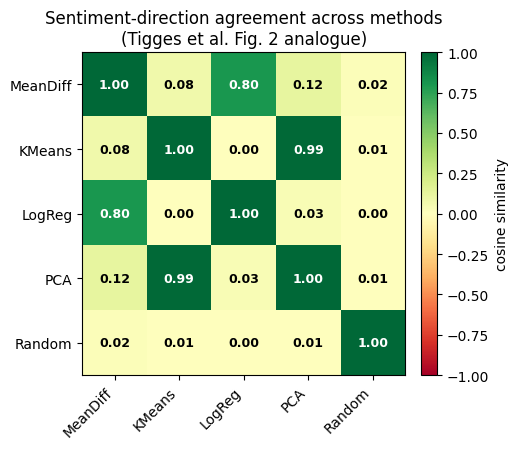

In [ ]:
# R.1 -- Four estimators, one axis? (paper Fig. 2). A linear representation predicts
# every reasonable direction-finder recovers ~the same axis; "Random" is the floor.
names = METHODS + ["Random"]
dirs = {m: direction(m, Xb, yb) for m in names}
C = np.array([[float(dirs[a] @ dirs[b]) for b in names] for a in names])  # unit vecs -> dot = cosine

print(f"pairwise cosine of sentiment directions (layer {LAYER}):")
print("          " + "".join(f"{n:>9}" for n in names))
for i, a in enumerate(names):
    print(f"{a:>9} " + "".join(f"{C[i, j]:>9.3f}" for j in range(len(names))))

fig, ax = plt.subplots(figsize=(5.4, 4.6))
im = ax.imshow(C, vmin=-1, vmax=1, cmap="RdYlGn")
ax.set_xticks(range(len(names)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{C[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(C[i, j]) > 0.6 else "black", fontweight="bold", fontsize=9)
plt.colorbar(im, fraction=0.046, pad=0.04).set_label("cosine similarity")
ax.set_title("Sentiment-direction agreement across methods\n(Tigges et al. Fig. 2 analogue)")
plt.tight_layout()
plt.show()

### R.2 The direction classifies, and projections separate (their Fig. 3 & Fig. 1)

Each direction is turned into a classifier exactly as in the paper — project onto it and threshold — but estimated under **scenario-grouped cross-validation** so a scenario's negative and positive halves never straddle the train/test split. The paper's Figure-3 accuracies (GPT2-small, layer 0: K-means .78, PCA .81, Mean Diff .80, LR .89) are shown alongside for reference. The histogram is our analogue of their Figure 1 — how cleanly negative vs. positive separate along the Mean-Difference axis (summarised by AUC and Cohen's *d*).

   method  bal-acc  +/-sd    paper Fig.3 (GPT2-small L0)
----------------------------------------------------
 MeanDiff    0.979  0.018    .80
   KMeans    0.501  0.002    .78
   LogReg    0.998  0.004    .89
      PCA    0.501  0.002    .81

Mean-Difference axis: AUC=0.998, Cohen's d=4.15


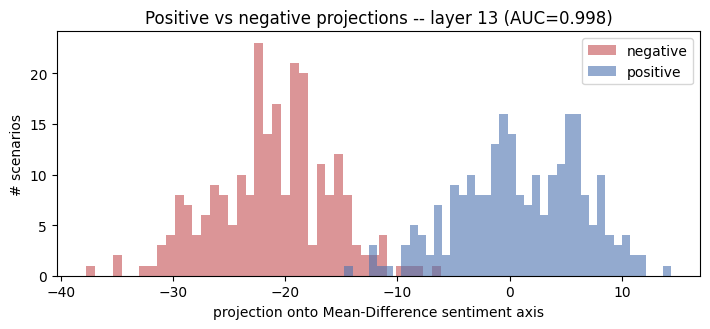

In [ ]:
# R.2 -- Does the direction classify, and do projections separate? (paper Fig. 3 & Fig. 1)
# Scenario-grouped CV: estimate the direction + a midpoint threshold on train scenarios,
# label held-out scenarios by the side of the threshold they project onto.
def cv_direction_accuracy(method, X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=min(n_splits, len(set(groups))))
    accs = []
    for tr, te in gkf.split(X, y, groups):
        d = direction(method, X[tr], y[tr])
        thr = 0.5 * ((X[tr][y[tr] == 1] @ d).mean() + (X[tr][y[tr] == 0] @ d).mean())
        accs.append(balanced_accuracy_score(y[te], (X[te] @ d > thr).astype(int)))
    return float(np.mean(accs)), float(np.std(accs))


print(f"{'method':>9}{'bal-acc':>9}{'+/-sd':>7}    paper Fig.3 (GPT2-small L0)")
print("-" * 52)
ref = {"MeanDiff": ".80", "KMeans": ".78", "LogReg": ".89", "PCA": ".81"}
for m in METHODS:
    mu, sd = cv_direction_accuracy(m, Xb, yb, scen_b)
    print(f"{m:>9}{mu:>9.3f}{sd:>7.3f}    {ref[m]}")

d_md = direction("MeanDiff", Xb, yb)
proj = Xb @ d_md
auc = roc_auc_score(yb, proj)
pooled_sd = np.sqrt(0.5 * (proj[yb == 1].var(ddof=1) + proj[yb == 0].var(ddof=1)))
cohen_d = (proj[yb == 1].mean() - proj[yb == 0].mean()) / pooled_sd
print(f"\nMean-Difference axis: AUC={auc:.3f}, Cohen's d={cohen_d:.2f}")

fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.hist(proj[yb == 0], bins=40, alpha=0.6, color="#C44E52", label="negative")
ax.hist(proj[yb == 1], bins=40, alpha=0.6, color="#4C72B0", label="positive")
ax.set_xlabel("projection onto Mean-Difference sentiment axis")
ax.set_ylabel("# scenarios")
ax.set_title(f"Positive vs negative projections -- layer {LAYER} (AUC={auc:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

### R.3 Generalization across languages (their Fig. 1)

The paper's headline robustness check is that *one* direction tracks sentiment across wildly different contexts (English web text and French prose). Our matched EN/IT design gives a clean version: fit the Mean-Difference direction on one language, classify the other, and measure the cosine between the two languages' directions.

In [ ]:
# R.3 -- Does one direction transfer across contexts? The paper shows a single axis
# colours sentiment in English OpenWebText *and* French Harry Potter (Fig. 1). Our
# analogue: fit the direction on one language, classify the other.
def transfer_accuracy(method, X, y, langs, src, dst):
    s, t = langs == src, langs == dst
    d = direction(method, X[s], y[s])
    thr = 0.5 * ((X[s][y[s] == 1] @ d).mean() + (X[s][y[s] == 0] @ d).mean())
    return balanced_accuracy_score(y[t], (X[t] @ d > thr).astype(int))


langs_uniq = sorted(set(lang_b))
print(f"cross-language transfer of the Mean-Difference direction (layer {LAYER}):")
for src in langs_uniq:
    for dst in langs_uniq:
        if src != dst:
            print(f"  train {src} -> test {dst}: balanced acc = "
                  f"{transfer_accuracy('MeanDiff', Xb, yb, lang_b, src, dst):.3f}")
if len(langs_uniq) == 2:
    a, b = langs_uniq
    da = direction("MeanDiff", Xb[lang_b == a], yb[lang_b == a])
    db = direction("MeanDiff", Xb[lang_b == b], yb[lang_b == b])
    print(f"  cosine(dir_{a}, dir_{b}) = {float(da @ db):.3f}")

cross-language transfer of the Mean-Difference direction (layer 13):
  train en -> test it: balanced acc = 0.996
  train it -> test en: balanced acc = 0.879
  cosine(dir_en, dir_it) = 0.867


### R.5 Removing the confound: within-scenario centering

R.1–R.2 showed exactly the predicted split: Mean Difference and Logistic Regression recover sentiment and classify near-perfectly, while PCA and K-means agree with *each other*, sit orthogonal to the supervised axis, and classify at chance — because the dominant axis of variation in this corpus is language/topic, not sentiment.

Now we apply the precaution from §5 of the politeness notebook — the **within-scenario (fixed-effects) transform**. Each scenario contributes a matched `negative`/`positive` pair; `within_center` subtracts that scenario's own two-level mean, removing the per-scenario baseline (language, topic, invariant content) and leaving only the within-scenario sentiment shift. For a two-level contrast this makes each scenario's two points exactly antipodal, $\pm\tfrac{1}{2}(\text{positive}-\text{negative})$, so the *only* variance left across the dataset is the sentiment movement itself.

**Prediction.** With the language/topic variance gone, the dominant axis now *is* sentiment — so the unsupervised finders (PCA, K-means) should recover the same direction as the supervised ones, and their classification accuracy should jump from chance toward the supervised level. Below, we replot the R.1 agreement matrix and the R.2 projection-separation histogram, each as **raw vs within-scenario centered**, alongside the raw→centered accuracy table.

*(This is the binary analogue of what §5 does for the full ordinal ladder: the supervised story survives pooling, but the unsupervised — and therefore the confound-blind — view of the geometry is only trustworthy once each scenario is used as its own control.)*

within-scenario centered neg/pos contrast at layer 13: 474 vectors over 237 complete scenarios (raw R.1 used 475)

   method      raw  centered   (R.2 -> R.5)
---------------------------------------
 MeanDiff    0.979     1.000
   KMeans    0.501     1.000
   LogReg    0.998     1.000
      PCA    0.501     1.000


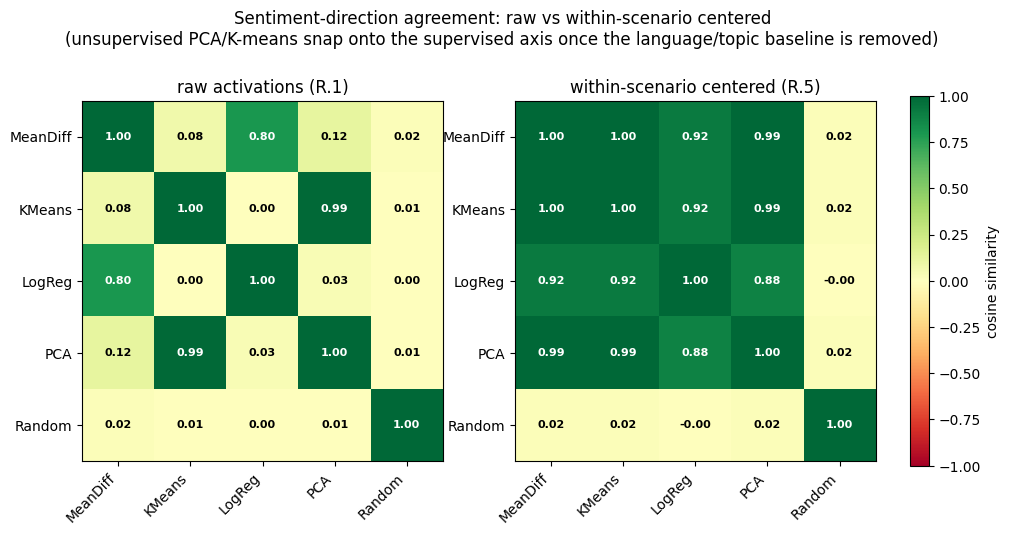

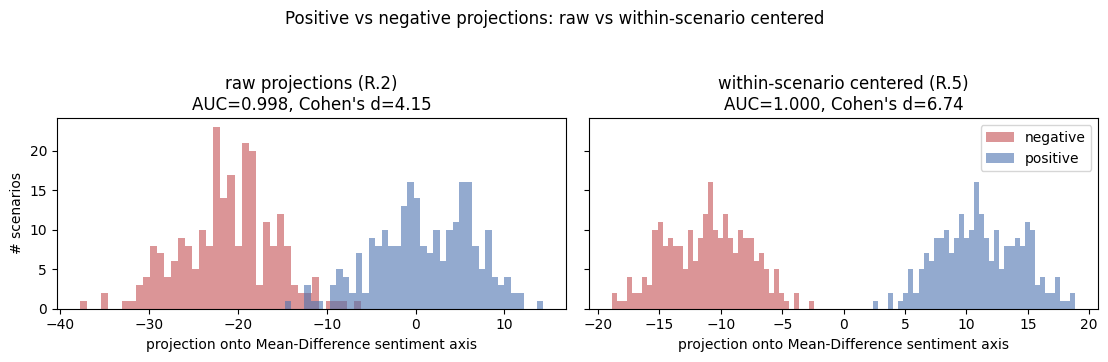

In [ ]:
# R.5 -- Apply the §5 precaution to the binary contrast: the within-scenario
# (fixed-effects) transform. `within_center` subtracts each scenario's own
# {neg,pos} mean, removing the language/topic baseline and leaving only the
# sentiment shift; then we re-run R.1 (agreement) and R.2 (classification).
centered = within_center(activations, [NEG, POS], trait=TRAIT)   # {(trait,level,sid): vec}
Xc, yc, scen_c, lang_c = binary_table(centered)
print(f"within-scenario centered neg/pos contrast at layer {LAYER}: "
      f"{Xc.shape[0]} vectors over {len(set(scen_c))} complete scenarios "
      f"(raw R.1 used {Xb.shape[0]})")

# Cross-method agreement after centering (compare to R.1's raw matrix C).
dirs_c = {m: direction(m, Xc, yc) for m in names}
Cc = np.array([[float(dirs_c[a] @ dirs_c[b]) for b in names] for a in names])

# Scenario-grouped classification: raw (R.2) vs within-scenario centered (R.5).
print(f"\n{'method':>9}{'raw':>9}{'centered':>10}   (R.2 -> R.5)")
print("-" * 39)
for m in METHODS:
    raw = cv_direction_accuracy(m, Xb, yb, scen_b)[0]
    cen = cv_direction_accuracy(m, Xc, yc, scen_c)[0]
    print(f"{m:>9}{raw:>9.3f}{cen:>10.3f}")

# R.1 plots: direction agreement raw vs centered.
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8))
for ax, (M, title) in zip(axes, [(C, "raw activations (R.1)"),
                                 (Cc, "within-scenario centered (R.5)")]):
    im = ax.imshow(M, vmin=-1, vmax=1, cmap="RdYlGn")
    ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right"); ax.set_yticklabels(names)
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                    color="white" if abs(M[i, j]) > 0.6 else "black", fontweight="bold", fontsize=8)
    ax.set_title(title)
fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04).set_label("cosine similarity")
fig.suptitle("Sentiment-direction agreement: raw vs within-scenario centered\n"
             "(unsupervised PCA/K-means snap onto the supervised axis once the language/topic baseline is removed)",
             y=1.06)
plt.show()

# R.2 plots: projection separation raw vs centered (Mean-Difference axis).
def projection_stats(X, y):
    d = direction("MeanDiff", X, y)
    proj = X @ d
    auc = roc_auc_score(y, proj)
    pooled_sd = np.sqrt(0.5 * (proj[y == 1].var(ddof=1) + proj[y == 0].var(ddof=1)))
    cohen_d = ((proj[y == 1].mean() - proj[y == 0].mean()) / pooled_sd) if pooled_sd > 0 else float("inf")
    return proj, auc, cohen_d

proj_raw, auc_raw, cd_raw = projection_stats(Xb, yb)
proj_cen, auc_cen, cd_cen = projection_stats(Xc, yc)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.4), sharey=True)
for ax, (proj, y, title, auc, cd) in zip(
    axes,
    [
        (proj_raw, yb, "raw projections (R.2)", auc_raw, cd_raw),
        (proj_cen, yc, "within-scenario centered (R.5)", auc_cen, cd_cen),
    ],
 ):
    ax.hist(proj[y == 0], bins=40, alpha=0.6, color="#C44E52", label="negative")
    ax.hist(proj[y == 1], bins=40, alpha=0.6, color="#4C72B0", label="positive")
    ax.set_xlabel("projection onto Mean-Difference sentiment axis")
    ax.set_title(f"{title}\nAUC={auc:.3f}, Cohen's d={cd:.2f}")
axes[0].set_ylabel("# scenarios")
axes[1].legend()
fig.suptitle("Positive vs negative projections: raw vs within-scenario centered", y=1.05)
plt.tight_layout()
plt.show()

### R.6 The other adjacent contrasts (positive–neutral, neutral–negative)

Tigges et al. only studied the extreme **negative/positive** pair. Politeness is *ordinal* (negative → neutral → positive), so the sharper test is whether each **adjacent half-step** carries the same linear structure as the full span. We repeat the R.5 analysis — with all the same precautions — on the two adjacent contrasts:

- **neutral → positive** (the *polite* half-step)
- **negative → neutral** (the *impolite* half-step)

Precautions carried over from R.5: the **within-scenario (fixed-effects) centering** subtracts each scenario's own two-level mean (an equal-weight midpoint, so paraphrase-count imbalance cannot skew it), removing the language/topic baseline; **scenario-grouped CV** keeps a scenario's two levels from splitting across train/test. Each half-step spans a *smaller* shift than the full neg/pos contrast, so we expect noisier separation — the question is whether the unsupervised finders (PCA, K-means) still snap onto the supervised axis once the baseline is removed, exactly as they did for neg/pos in R.5.

positive vs neutral  (layer 13)
  raw: 463 vectors / 238 scenarios   centered: 450 vectors / 225 complete scenarios

     method      raw  centered
  ----------------------------
   MeanDiff    0.760     0.987
     KMeans    0.501     0.987
     LogReg    0.935     0.996
        PCA    0.508     0.973


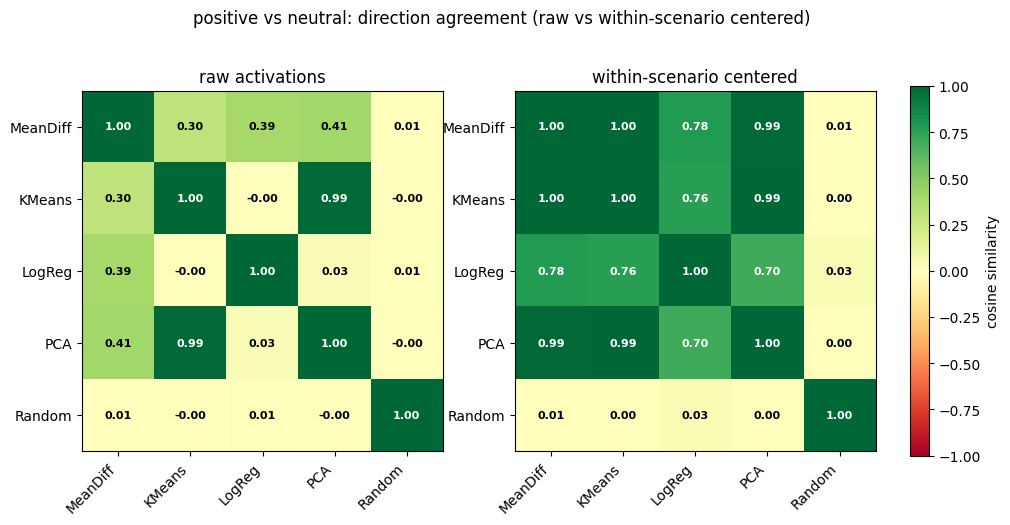

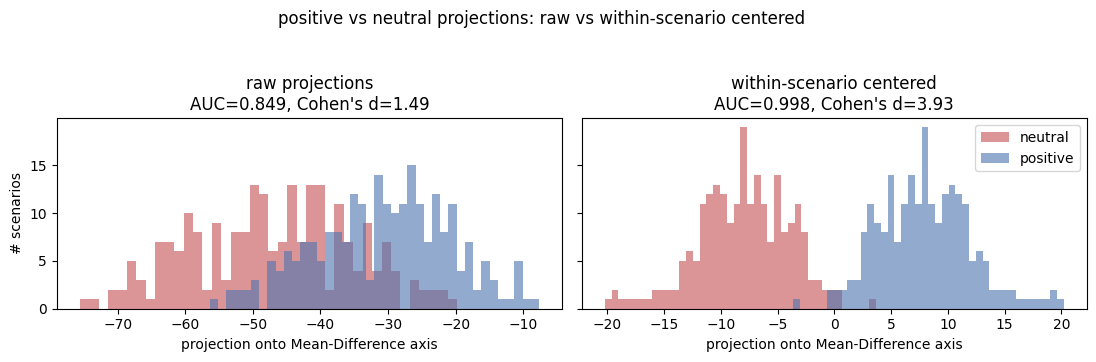

neutral vs negative  (layer 13)
  raw: 462 vectors / 238 scenarios   centered: 448 vectors / 224 complete scenarios

     method      raw  centered
  ----------------------------
   MeanDiff    0.924     1.000
     KMeans    0.500     1.000
     LogReg    0.985     1.000
        PCA    0.507     1.000


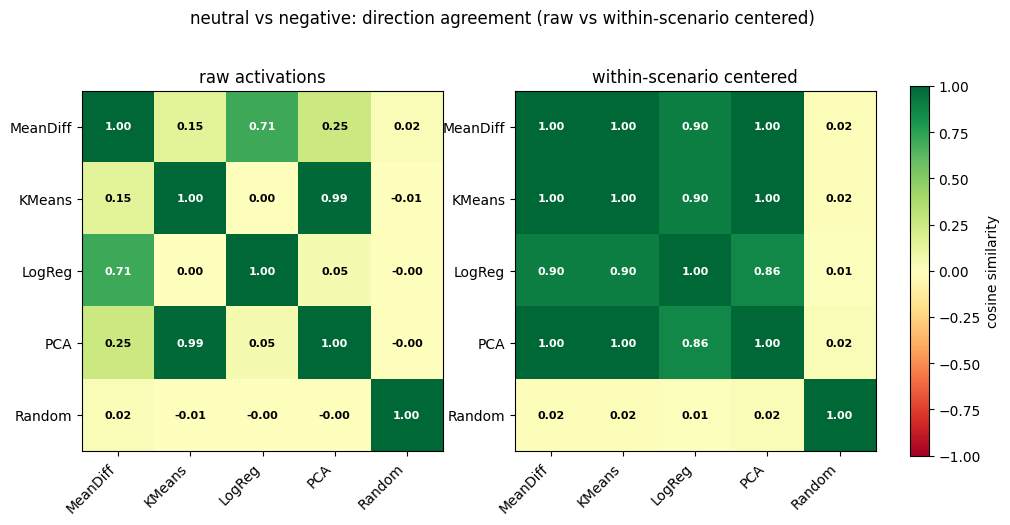

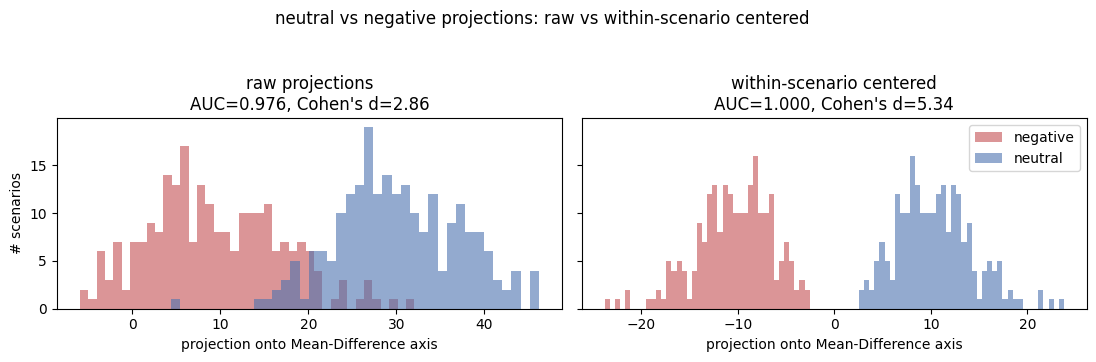

In [ ]:
# R.6 -- The two adjacent half-steps, with the R.5 precautions. The paper studied
# only the extreme neg/pos contrast; politeness is ordinal, so we repeat the
# within-scenario analysis on (neutral -> positive) and (negative -> neutral).
# Reuses R.1/R.2/R.5 machinery: `direction`, `cv_direction_accuracy`,
# `within_center`, `projection_stats`, `names`, `METHODS`.
NEUT = "neutral"
PAIRS = [("neutral", "positive"), ("negative", "neutral")]  # (lo, hi); direction -> hi


def pair_table(acts, lo, hi, trait=TRAIT):
    """(X, y, scenarios, languages) for a lo/hi contrast; y=1 for the hi level."""
    rows, y, scen, langs = [], [], [], []
    for (t, lvl, sid), vec in acts.items():
        if t != trait or lvl not in (lo, hi):
            continue
        rows.append(np.asarray(vec, dtype=np.float64))
        y.append(1 if lvl == hi else 0)
        scen.append(sid)
        langs.append(scen2lang.get(sid, "?"))
    return np.stack(rows), np.array(y), np.array(scen), np.array(langs)


for lo, hi in PAIRS:
    Xr, yr, scen_r, _ = pair_table(activations, lo, hi)           # raw
    cen = within_center(activations, [lo, hi], trait=TRAIT)       # within-scenario centered
    Xk, yk, scen_k, _ = pair_table(cen, lo, hi)
    print("=" * 60)
    print(f"{hi} vs {lo}  (layer {LAYER})")
    print(f"  raw: {Xr.shape[0]} vectors / {len(set(scen_r))} scenarios   "
          f"centered: {Xk.shape[0]} vectors / {len(set(scen_k))} complete scenarios")

    # Cross-method direction agreement, raw vs centered (R.1 analogue).
    dr = {m: direction(m, Xr, yr) for m in names}
    dk = {m: direction(m, Xk, yk) for m in names}
    Cr = np.array([[float(dr[a] @ dr[b]) for b in names] for a in names])
    Ck = np.array([[float(dk[a] @ dk[b]) for b in names] for a in names])

    # Scenario-grouped CV classification, raw vs centered (R.2 -> R.5 analogue).
    print(f"\n  {'method':>9}{'raw':>9}{'centered':>10}")
    print("  " + "-" * 28)
    for m in METHODS:
        r = cv_direction_accuracy(m, Xr, yr, scen_r)[0]
        k = cv_direction_accuracy(m, Xk, yk, scen_k)[0]
        print(f"  {m:>9}{r:>9.3f}{k:>10.3f}")

    # Agreement heatmaps.
    fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8))
    for ax, (M, ttl) in zip(axes, [(Cr, "raw activations"),
                                   (Ck, "within-scenario centered")]):
        im = ax.imshow(M, vmin=-1, vmax=1, cmap="RdYlGn")
        ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
        ax.set_xticklabels(names, rotation=45, ha="right"); ax.set_yticklabels(names)
        for i in range(len(names)):
            for j in range(len(names)):
                ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                        color="white" if abs(M[i, j]) > 0.6 else "black",
                        fontweight="bold", fontsize=8)
        ax.set_title(ttl)
    fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04).set_label("cosine similarity")
    fig.suptitle(f"{hi} vs {lo}: direction agreement (raw vs within-scenario centered)", y=1.04)
    plt.show()

    # Projection separation on the Mean-Difference axis, raw vs centered.
    pr, aucr, cdr = projection_stats(Xr, yr)
    pk, auck, cdk = projection_stats(Xk, yk)
    fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.4), sharey=True)
    for ax, (proj, yy, ttl, auc, cd) in zip(axes, [
        (pr, yr, "raw projections", aucr, cdr),
        (pk, yk, "within-scenario centered", auck, cdk),
    ]):
        ax.hist(proj[yy == 0], bins=40, alpha=0.6, color="#C44E52", label=lo)
        ax.hist(proj[yy == 1], bins=40, alpha=0.6, color="#4C72B0", label=hi)
        ax.set_xlabel("projection onto Mean-Difference axis")
        ax.set_title(f"{ttl}\nAUC={auc:.3f}, Cohen's d={cd:.2f}")
    axes[0].set_ylabel("# scenarios")
    axes[1].legend()
    fig.suptitle(f"{hi} vs {lo} projections: raw vs within-scenario centered", y=1.05)
    plt.tight_layout()
    plt.show()

### R.5 Layer Sweep

The paper recovers the direction at every layer. Here we sweep all layers (one multi-layer forward pass), tracking both the Mean-Difference classification accuracy and the mean cross-method agreement, to locate where the linear positive/negative structure is strongest and to sanity-check the focal layer 13.

Loaded 26-layer sweep from ../../data/v2/activations/layer_*/


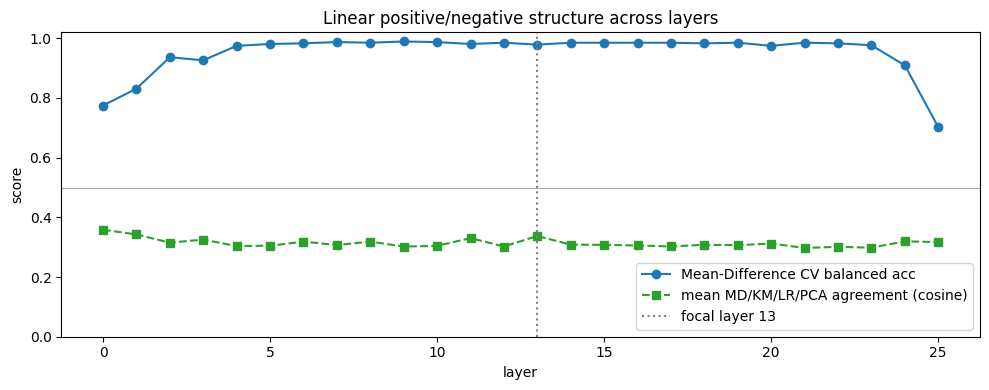

In [ ]:
# R.4 -- Where does the linear pos/neg structure live? Re-estimate the direction at
# every layer and track accuracy + cross-method agreement.
acts_multi = load_representations(REP_DIR)
rep_layers = sorted({l for (_, _, _, l) in acts_multi})
print(f"Loaded {len(rep_layers)}-layer sweep from {REP_DIR}")

sweep_acc, sweep_cos = [], []
for L in rep_layers:
    aL = {(t, i, s): v for (t, i, s, l), v in acts_multi.items() if l == L}
    X, y, scen, _ = binary_table(aL)
    sweep_acc.append(cv_direction_accuracy("MeanDiff", X, y, scen)[0])
    dset = {m: direction(m, X, y) for m in METHODS}
    sweep_cos.append(float(np.mean([dset[a] @ dset[b]
                                    for a in METHODS for b in METHODS if a < b])))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rep_layers, sweep_acc, "o-", label="Mean-Difference CV balanced acc")
ax.plot(rep_layers, sweep_cos, "s--", color="C2", label="mean MD/KM/LR/PCA agreement (cosine)")
ax.axvline(LAYER, color="gray", ls=":", lw=1.5, label=f"focal layer {LAYER}")
ax.axhline(0.5, color="k", lw=0.6, alpha=0.4)
ax.set_xlabel("layer")
ax.set_ylabel("score")
ax.set_ylim(0, 1.02)
ax.set_title("Linear positive/negative structure across layers")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()